In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight


In [2]:
data_org = pd.read_csv("C:\\Users\\pooja\\OneDrive\\Desktop\\Documents\\IITM\\DAL\\lab 7\\to_uci\\aps_failure_training_set.csv")
data_org.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [3]:
#There are lot of "na" values in the dataset, which need to be replaced before data processing.
data_org['ab_000'].iloc[0]
data_org.isnull().sum().unique()
#none of the missing values are showing up. This means that they have been stored as strings. We can replace 'na' with median of the feature. 

array([0], dtype=int64)

In [4]:
data1 = data_org
na_columns = data1.columns[data1.apply(lambda col: col.astype(str).str.contains('na').any())]
na_columns_list = na_columns.tolist()

print("Columns containing the string '{}': {}".format('na', na_columns_list))

for col in na_columns_list:
    data1[col] = pd.to_numeric(data1[col], errors='coerce')
    mean_value = data1[col].median()
    data1[col].fillna(mean_value, inplace=True) 
data1.info()

Columns containing the string 'na': ['ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000', 'cl_0

In [5]:
#We need to scale the values before data processing to get better results.
scaler = StandardScaler()
data_class = data1['class']
data_features = data1.drop(['class'],axis=1)
data1_scaled = scaler.fit_transform(data_features)

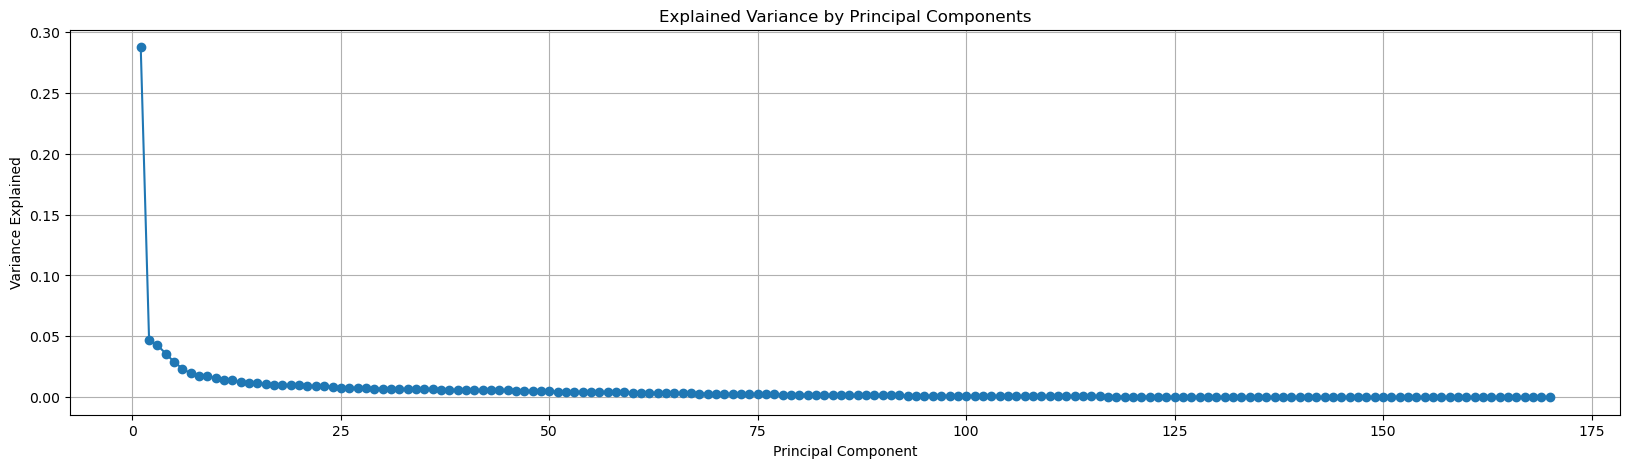

In [6]:
#The number of features is huge. Running models on 171 features will be time and memory complex.
#Hence, dimensionality reduction is necessary to reduce time complexity.
pca = PCA()
pca.fit(data1_scaled)

explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(20, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [7]:
#The graph shows that only a first few components are important for explaining the variance of the data. 
#Taking 10 components will ensure that maximum variance is explained.

pca = PCA(n_components=10)
X_train_1 = pca.fit_transform(data1_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_train_1, data_class, test_size=0.3, random_state=42)

TASK 1

In [8]:
def svc_task1(X_train,X_test,y_train,y_test):
    param_grid_svc = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],                      
    'gamma': ['scale', 'auto'],                
    }
    
    svc = SVC()
    svc_task1 = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
    svc_task1.fit(X_train, y_train)
    print("Best SVC Parameters", svc_task1.best_params_)
    svc_best = svc_task1.best_estimator_
    svc_best.fit(X_train,y_train)
    svc_task1_pred=svc_best.predict(X_test)
    print("\nf1 score:", f1_score(y_test, svc_task1_pred, pos_label="pos"))

def lr_task1(X_train,X_test,y_train,y_test):
    param_grid_lr = {
    'C': [0.01, 0.1, 1, 10], 
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear','saga','lbfgs']
    }
    lr = LogisticRegression()
    lr_task1 = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
    lr_task1.fit(X_train, y_train)
    lr_best = lr_task1.best_estimator_
    lr_best.fit(X_train,y_train)
    lr_task1_pred=lr_best.predict(X_test)
    print("Best Parameters:", lr_task1.best_params_)
    print("\nf1 score:", f1_score(y_test, lr_task1_pred, pos_label="pos"))

def dt_task1(X_train,X_test,y_train,y_test):
    param_grid_dt = {
    'max_depth': [3, 5, 10], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
    }
    dec_tree=DecisionTreeClassifier()
    dt_task1 = GridSearchCV(dec_tree, param_grid_dt, cv=5, scoring='accuracy')
    dt_task1.fit(X_train, y_train)
    dt_best = dt_task1.best_estimator_
    dt_best.fit(X_train,y_train)
    dt_task1_pred=dt_best.predict(X_test)
    print("Best Parameters:", dt_task1.best_params_)
    print("\nf1 score:", f1_score(y_test, dt_task1_pred, pos_label="pos"))

In [28]:
svc_task1(X_train,X_test,y_train,y_test)

Best SVC Parameters {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

f1 score: 0.6591760299625468


In [9]:
lr_task1(X_train,X_test,y_train,y_test)

c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}

f1 score: 0.4336283185840708


In [10]:
dt_task1(X_train,X_test,y_train,y_test)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

f1 score: 0.5576208178438661


TASK 2(A)

In [11]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

def svc_task2a(X_train,X_test,y_train,y_test):
    param_grid_svc = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],                      
    'gamma': ['scale', 'auto'],                
    }
    
    svc = SVC()
    svc_task2a = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
    svc_task2a.fit(X_train, y_train)
    print("Best SVC Parameters", svc_task2a.best_params_)
    svc_best = svc_task2a.best_estimator_
    svc_best.fit(X_train,y_train)
    svc_task2a_pred=svc_best.predict(X_test)
    print("\nf1 score macro:", round(f1_score(y_test, svc_task2a_pred, pos_label="pos", average="macro"),2))

def lr_task2a(X_train,X_test,y_train,y_test):
    param_grid_lr = {
    'C': [0.01, 0.1, 1, 10], 
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear','saga','lbfgs']
    }
    lr = LogisticRegression()
    lr_task2a = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
    lr_task2a.fit(X_train, y_train)
    lr_best = lr_task2a.best_estimator_
    lr_best.fit(X_train,y_train)
    lr_task2a_pred=lr_best.predict(X_test)
    print("Best Parameters:", lr_task2a.best_params_)
    print("\nf1 score macro:", round(f1_score(y_test, lr_task2a_pred, pos_label="pos", average="macro"),2))

def dt_task2a(X_train,X_test,y_train,y_test):
    param_grid_dt = {
    'max_depth': [3, 5, 10], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
    }
    dec_tree=DecisionTreeClassifier()
    dt_task2a = GridSearchCV(dec_tree, param_grid_dt, cv=5, scoring='accuracy')
    dt_task2a.fit(X_train, y_train)
    dt_best = dt_task2a.best_estimator_
    dt_best.fit(X_train,y_train)
    dt_task2a_pred=dt_best.predict(X_test)
    print("Best Parameters:", dt_task2a.best_params_)
    print("\nf1 score macro:", round(f1_score(y_test, dt_task2a_pred, pos_label="pos", average="macro"),2))

In [27]:
svc_task2a(X_resampled, X_test, y_resampled, y_test)

Best SVC Parameters {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}

f1 score macro: 0.64


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [12]:
lr_task2a(X_resampled, X_test, y_resampled, y_test)

c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}

f1 score macro: 0.69


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [13]:
dt_task2a(X_resampled, X_test, y_resampled, y_test)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}

f1 score macro: 0.65


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [14]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_oversampled, y_oversampled= ros.fit_resample(X_train, y_train)

In [26]:
svc_task2a(X_oversampled, X_test, y_oversampled, y_test)

Best SVC Parameters {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

f1 score macro: 0.63


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [15]:
lr_task2a(X_oversampled, X_test, y_oversampled, y_test)

c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

f1 score macro: 0.71


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [16]:
dt_task2a(X_oversampled, X_test, y_oversampled, y_test)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

f1 score macro: 0.72


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


TASK 2 (b)

In [17]:

def svc_task2b(X_train,X_test,y_train,y_test):
    param_grid_svc = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],                      
    'gamma': ['scale', 'auto'],                
    }
    
    svc = SVC(class_weight='balanced')
    svc_task2 = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
    svc_task2.fit(X_train, y_train)
    svc_best = svc_task2.best_estimator_
    svc_best.fit(X_train,y_train)
    svc_task2_pred=svc_best.predict(X_test)
    print("Best Parameters:", svc_task2.best_params_)
    print("\nf1 score macro:", f1_score(y_test, svc_task2_pred, average='macro', pos_label="pos"))

def lr_task2b(X_train,X_test,y_train,y_test):
    param_grid_lr = {
    'C': [0.01, 0.1, 1], 
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear','lbfgs']
    }
    lr = LogisticRegression(class_weight='balanced')
    lr_task2 = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
    lr_task2.fit(X_train, y_train)
    lr_best = lr_task2.best_estimator_
    lr_best.fit(X_train,y_train)
    lr_task2_pred=lr_best.predict(X_test)
    print("Best Parameters:", lr_task2.best_params_)
    print("\nf1 score macro:", f1_score(y_test, lr_task2_pred, average='macro', pos_label="pos"))

def dt_task2b(X_train,X_test,y_train,y_test):
    param_grid_dt = {
    'max_depth': [3, 5, 10], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
    }
    dec_tree=DecisionTreeClassifier(class_weight='balanced')
    dt_task2 = GridSearchCV(dec_tree, param_grid_dt, cv=5, scoring='accuracy')
    dt_task2.fit(X_train, y_train)
    dt_best = dt_task2.best_estimator_
    dt_best.fit(X_train,y_train)
    dt_task2_pred=dt_best.predict(X_test)
    print("Best Params:", dt_task2.best_params_)
    print("\nf1 score macro:", f1_score(y_test, dt_task2_pred, average='macro', pos_label="pos"))


In [25]:
svc_task2b(X_train,X_test,y_train,y_test)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

f1 score macro: 0.6314141170802215


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [18]:
lr_task2b(X_train,X_test,y_train,y_test)

c:\Users\pooja\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\pooja\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1461, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 447, in _check_solver
    raise ValueError(
Valu

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

f1 score macro: 0.7093572829302115


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [19]:
dt_task2b(X_train, X_test, y_train, y_test)



Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

f1 score macro: 0.7244007133206528


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


TASK 2c

In [20]:

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.where(y_train == 0, class_weights[0], class_weights[1])

In [21]:
def svc_task2c(X_train,X_test,y_train,y_test):
    param_grid_svc = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],                      
    'gamma': ['scale', 'auto'],                
    }
    
    svc = SVC()
    svc_task2c = GridSearchCV(svc, param_grid_svc, cv=10, scoring='accuracy')
    svc_task2c.fit(X_train, y_train, sample_weight=sample_weights)
    print("Best SVC Parameters:", svc_task2c.best_params_)
    svc_best = svc_task2c.best_estimator_
    svc_best.fit(X_train,y_train)
    svc_task2c_pred=svc_best.predict(X_test)
    print("\nf1 score macro:", f1_score(y_test, svc_task2c_pred, average='macro', pos_label="pos"))

def lr_task2c(X_train,X_test,y_train,y_test):
    param_grid_lr = {
    'C': [0.01, 0.1, 1, 10], 
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear','saga','lbfgs']
    }
    lr = LogisticRegression()
    lr_task2c = GridSearchCV(lr, param_grid_lr, cv=10, scoring='accuracy')
    lr_task2c.fit(X_train, y_train, sample_weight=sample_weights)
    lr_best = lr_task2c.best_estimator_
    lr_best.fit(X_train,y_train)
    lr_task2c_pred=lr_best.predict(X_test)
    print("Best Parameters:", lr_task2c.best_params_)
    print("\nf1 score macro:\n", f1_score(y_test, lr_task2c_pred, average='macro', pos_label="pos"))

def dt_task2c(X_train,X_test,y_train,y_test):
    param_grid_dt = {
    'max_depth': [3, 5, 10], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
    }
    dec_tree=DecisionTreeClassifier()
    dt_task2c = GridSearchCV(dec_tree, param_grid_dt, cv=10, scoring='accuracy')
    dt_task2c.fit(X_train, y_train, sample_weight=sample_weights)
    dt_best = dt_task2c.best_estimator_
    dt_best.fit(X_train,y_train)
    dt_task2c_pred=dt_best.predict(X_test)
    print("Best Parameters:", dt_task2c.best_params_)
    print("\nf1 score macro:\n", f1_score(y_test, dt_task2c_pred, average='macro', pos_label="pos"))

In [24]:
svc_task2c(X_train,X_test,y_train,y_test)

Best SVC Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

f1 score macro: 0.5185210271660229


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [22]:
lr_task2c(X_train,X_test,y_train,y_test)

c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pooja\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

f1 score macro:
 0.7064918330543472


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [23]:
dt_task2c(X_train,X_test,y_train,y_test)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

f1 score macro:
 0.7762737356645986


c:\Users\pooja\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1370: UserWarning: Note that pos_label (set to 'pos') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
